<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/222222Pneumonia_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [161]:
import os
from google.colab import drive
import zipfile
from pathlib import Path
import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import torch.optim as optim
from PIL import Image
import torchvision
from sklearn.metrics import classification_report,roc_auc_score,confusion_matrix,precision_recall_curve

from torchvision import transforms,datasets,models
import torch
from torch.utils.data import DataLoader,ConcatDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [162]:
drive.mount('/content/drive')
datasetpathdrive='/content/drive/MyDrive/Chest X-Ray Images (Pneumonia).zip'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [163]:
with zipfile.ZipFile(datasetpathdrive,'r') as z:
  z.extractall('dataset')

Data loader

In [164]:
train_dataset_path=Path('/content/dataset/chest_xray/chest_xray/train')
test_dataset_path=Path('/content/dataset/chest_xray/chest_xray/test')
validation_dataset_path=Path('/content/dataset/chest_xray/chest_xray/val')



In [165]:

# separate transforms
train_transform = transforms.Compose([
    CenterCropPercent(crop_fraction=0.85),   # cut ~15% margin off all sides
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    CenterCropPercent(crop_fraction=0.85),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

# load train folder twice: once augmented, once plain (for merging + splitting)
train_data_aug = datasets.ImageFolder(root=train_dataset_path, transform=train_transform)
train_data_plain = datasets.ImageFolder(root=train_dataset_path, transform=eval_transform)
val_data_aug = datasets.ImageFolder(root=validation_dataset_path, transform=train_transform)
val_data_plain = datasets.ImageFolder(root=validation_dataset_path, transform=eval_transform)

# merge train + tiny official val, then make our OWN proper val split
full_aug = ConcatDataset([train_data_aug, val_data_aug])
full_plain = ConcatDataset([train_data_plain, val_data_plain])

torch.manual_seed(42)
indices = torch.randperm(len(full_aug)).tolist()
train_size = int(0.85 * len(full_aug))
train_idx, val_idx = indices[:train_size], indices[train_size:]

train_dataset = torch.utils.data.Subset(full_aug, train_idx)     # augmented
validation_dataset = torch.utils.data.Subset(full_plain, val_idx)  # not augmented

# official test set — untouched, used only once at the very end
test_dataset = datasets.ImageFolder(root=test_dataset_path, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("train dataset length:", len(train_dataset))
print("validation dataset length:", len(validation_dataset))
print("test dataset length:", len(test_dataset))

train dataset length: 4447
validation dataset length: 785
test dataset length: 624


EDA

In [166]:

class_names = train_data_plain.classes

def get_targets_from_subset(subset):
    """Extract labels from a Subset of a ConcatDataset."""
    concat_dataset = subset.dataset
    indices = subset.indices

    labels = []
    for idx in indices:
        _, label = concat_dataset[idx]
        labels.append(label)
    return labels

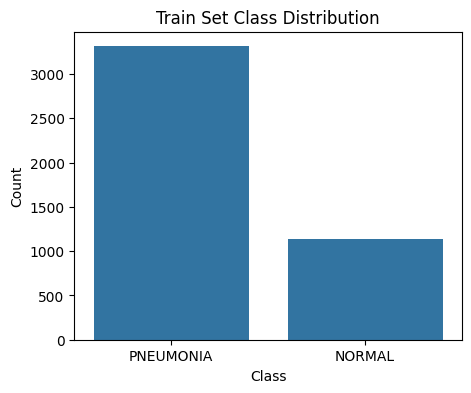

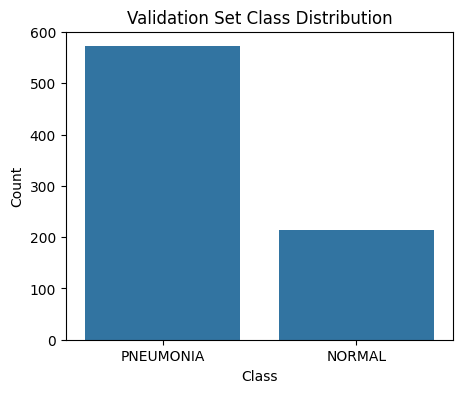

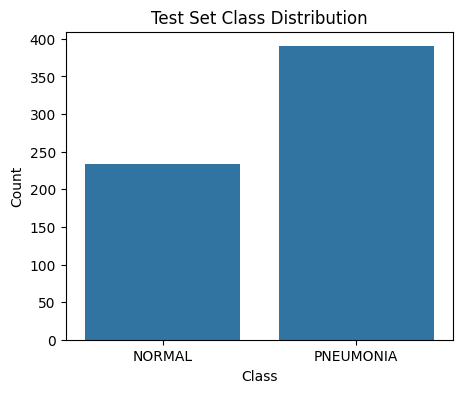

In [167]:
def plot_counts(targets, class_names, title):
    labels = [class_names[t] for t in targets]
    plt.figure(figsize=(5, 4))
    sns.countplot(x=labels)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

all_targets = train_data_plain.targets + val_data_plain.targets
train_targets = [all_targets[i] for i in train_idx]
val_targets = [all_targets[i] for i in val_idx]
test_targets = test_dataset.targets

plot_counts(train_targets, class_names, "Train Set Class Distribution")
plot_counts(val_targets, class_names, "Validation Set Class Distribution")
plot_counts(test_targets, class_names, "Test Set Class Distribution")

In [168]:
class_names=train_data_plain.classes
print(class_names)

targets=np.array(train_data_plain.targets + val_data_plain.targets)
class_counts=np.bincount(targets)
print(class_counts)

class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float).to(device)

['NORMAL', 'PNEUMONIA']
[1349 3883]


In [169]:
def show_images(dataset, class_name, n=50, cols=10):
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(cols * 1.5, rows * 1.5))

    indices = random.sample(range(len(dataset)), n)

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for plot_i, idx in enumerate(indices):
        image, label = dataset[idx]

        # Undo normalization
        image = image * std + mean

        # Convert CHW → HWC
        img = image.numpy().transpose((1, 2, 0))

        # Make sure values are between 0 and 1
        img = img.clip(0, 1)

        plt.subplot(rows, cols, plot_i + 1)
        plt.imshow(img)
        plt.title(class_name[label])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

['NORMAL', 'PNEUMONIA']


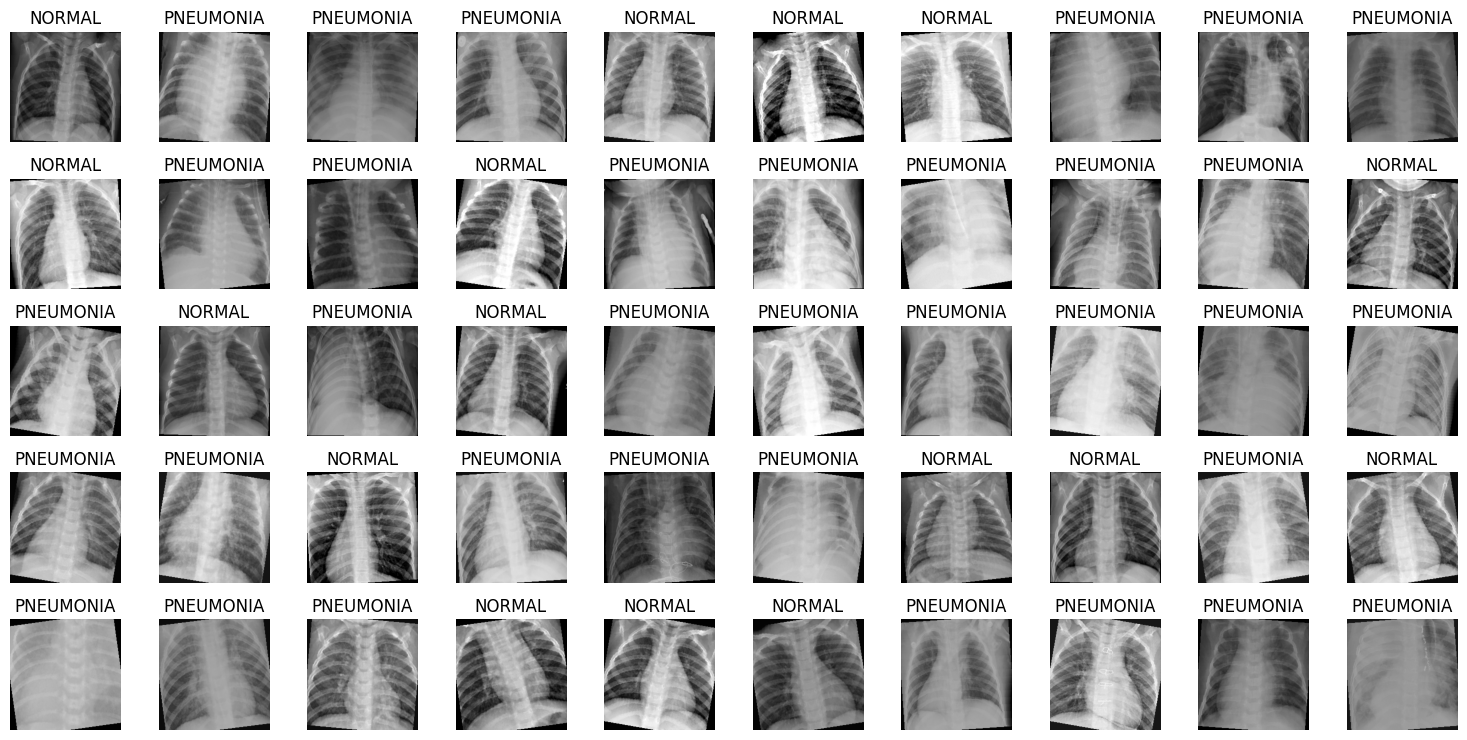

In [170]:
# images of train data
class_name=train_data_aug.classes
print(class_name)
show_images(train_data_aug,class_name)

['NORMAL', 'PNEUMONIA']


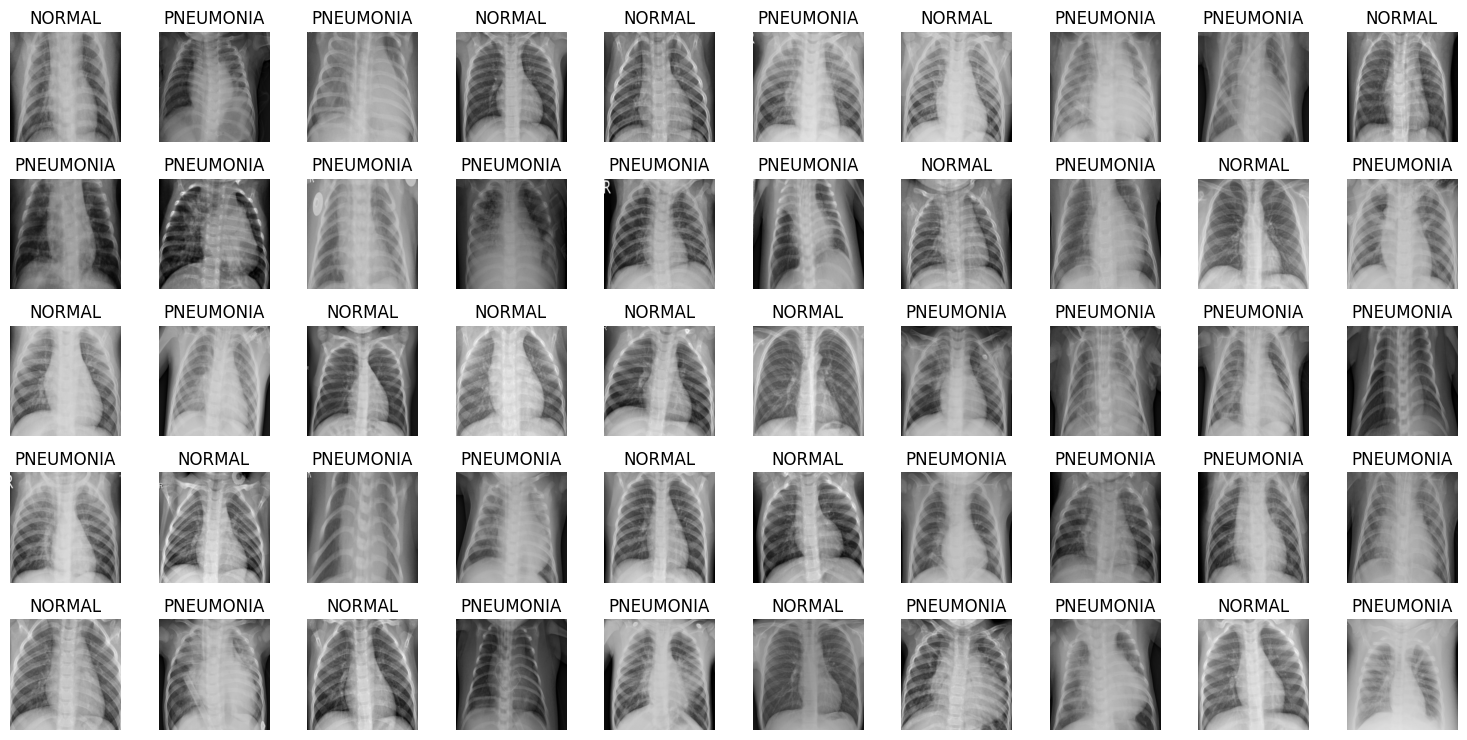

In [171]:
# images of test data
class_name=test_dataset.classes
print(class_name)
show_images(test_dataset,class_name)

**Modeling**

In [172]:

class CenterCropPercent:
    """Crops a fixed percentage margin off each side, before resizing."""
    def __init__(self, crop_fraction=0.85):
        self.crop_fraction = crop_fraction

    def __call__(self, img):
        w, h = img.size
        new_w, new_h = int(w * self.crop_fraction), int(h * self.crop_fraction)
        left = (w - new_w) // 2
        top = (h - new_h) // 2
        return img.crop((left, top, left + new_w, top + new_h))

In [173]:
model=models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False
model.fc=nn.Linear(model.fc.in_features,2)
model.to(device)

criterion=nn.CrossEntropyLoss(weight=class_weights)
optimizer=optim.Adam(model.parameters(),lr=0.001)

In [174]:

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return running_loss / total, correct / total, all_preds, all_labels, all_probs


In [175]:
num_epochs = 15
best_val_loss = float("inf")
patience, patience_counter = 3, 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, _, _, _ = evaluate(model, validation_loader, criterion)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")

Epoch 1/15 | Train Loss: 0.4082 Acc: 0.8251 | Val Loss: 0.2354 Acc: 0.9274
Epoch 2/15 | Train Loss: 0.2875 Acc: 0.8876 | Val Loss: 0.2596 Acc: 0.8561
Epoch 3/15 | Train Loss: 0.2557 Acc: 0.9022 | Val Loss: 0.1948 Acc: 0.9248
Epoch 4/15 | Train Loss: 0.2303 Acc: 0.9128 | Val Loss: 0.1821 Acc: 0.9389
Epoch 5/15 | Train Loss: 0.2355 Acc: 0.9060 | Val Loss: 0.2677 Acc: 0.8548
Epoch 6/15 | Train Loss: 0.2243 Acc: 0.9121 | Val Loss: 0.1786 Acc: 0.9287
Epoch 7/15 | Train Loss: 0.2113 Acc: 0.9204 | Val Loss: 0.1821 Acc: 0.9274
Epoch 8/15 | Train Loss: 0.2213 Acc: 0.9094 | Val Loss: 0.1717 Acc: 0.9503
Epoch 9/15 | Train Loss: 0.2102 Acc: 0.9181 | Val Loss: 0.1885 Acc: 0.9172
Epoch 10/15 | Train Loss: 0.2088 Acc: 0.9211 | Val Loss: 0.1694 Acc: 0.9478
Epoch 11/15 | Train Loss: 0.2017 Acc: 0.9231 | Val Loss: 0.1732 Acc: 0.9554
Epoch 12/15 | Train Loss: 0.1901 Acc: 0.9260 | Val Loss: 0.1678 Acc: 0.9439
Epoch 13/15 | Train Loss: 0.2065 Acc: 0.9204 | Val Loss: 0.1649 Acc: 0.9439
Epoch 14/15 | Train L

Evaluation

In [176]:
model.load_state_dict(torch.load("best_model.pth"))
test_loss, test_acc, preds, labels, probs = evaluate(model, test_loader, criterion)

print(f"Test Accuracy: {test_acc:.4f}")
print(classification_report(labels, preds, target_names=class_names))
print("AUC-ROC:", roc_auc_score(labels, probs))
print("Confusion Matrix:\n", confusion_matrix(labels, preds))

Test Accuracy: 0.9006
              precision    recall  f1-score   support

      NORMAL       0.96      0.76      0.85       234
   PNEUMONIA       0.87      0.98      0.93       390

    accuracy                           0.90       624
   macro avg       0.92      0.87      0.89       624
weighted avg       0.91      0.90      0.90       624

AUC-ROC: 0.9476495726495726
Confusion Matrix:
 [[179  55]
 [  7 383]]


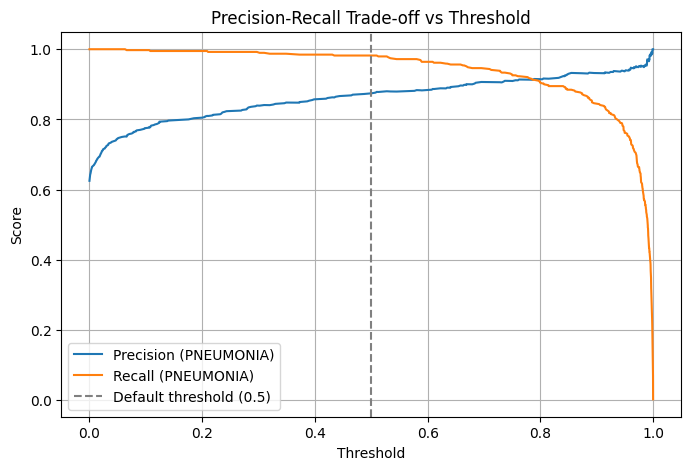

In [177]:


labels = np.array(labels)
probs = np.array(probs)

precision, recall, thresholds = precision_recall_curve(labels, probs)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label="Precision (PNEUMONIA)")
plt.plot(thresholds, recall[:-1], label="Recall (PNEUMONIA)")
plt.axvline(x=0.5, color='gray', linestyle='--', label="Default threshold (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [178]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_at_threshold(labels, probs, threshold, class_names):
    preds = (probs >= threshold).astype(int)
    print(f"\n--- Threshold = {threshold} ---")
    print(classification_report(labels, preds, target_names=class_names))
    print("Confusion Matrix:\n", confusion_matrix(labels, preds))

for t in [0.5, 0.55, 0.6, 0.65, 0.7]:
    evaluate_at_threshold(labels, probs, t, class_names)


--- Threshold = 0.5 ---
              precision    recall  f1-score   support

      NORMAL       0.96      0.76      0.85       234
   PNEUMONIA       0.87      0.98      0.93       390

    accuracy                           0.90       624
   macro avg       0.92      0.87      0.89       624
weighted avg       0.91      0.90      0.90       624

Confusion Matrix:
 [[179  55]
 [  7 383]]

--- Threshold = 0.55 ---
              precision    recall  f1-score   support

      NORMAL       0.94      0.78      0.86       234
   PNEUMONIA       0.88      0.97      0.92       390

    accuracy                           0.90       624
   macro avg       0.91      0.88      0.89       624
weighted avg       0.90      0.90      0.90       624

Confusion Matrix:
 [[183  51]
 [ 11 379]]

--- Threshold = 0.6 ---
              precision    recall  f1-score   support

      NORMAL       0.93      0.79      0.85       234
   PNEUMONIA       0.88      0.96      0.92       390

    accuracy          

GradCam

In [179]:

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # hooks to capture activations (forward) and gradients (backward)
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
      self.model.eval()
      input_tensor = input_tensor.clone().requires_grad_(True)  # <-- new line, forces gradient flow

      output = self.model(input_tensor)

      self.model.zero_grad()
      score = output[:, class_idx]
      score.backward()

      weights = self.gradients.mean(dim=(2, 3), keepdim=True)
      cam = (weights * self.activations).sum(dim=1, keepdim=True)
      cam = F.relu(cam)

      cam = F.interpolate(cam, size=input_tensor.shape[2:], mode='bilinear', align_corners=False)
      cam = cam.squeeze().cpu().numpy()
      cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
      return cam

In [180]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

target_layer=model.layer4[-1]
gradcam=GradCAM(model,target_layer)

In [181]:
def show_gradcam(image_tensor, cam, true_label, pred_label, class_names, ax=None):
    # unnormalize if you used ImageNet normalization; skip if you didn't normalize
    img = image_tensor.cpu().numpy().transpose(1, 2, 0)
    img = np.clip(img, 0, 1)

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    overlay = 0.5 * img + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)

    if ax is None:
        plt.imshow(overlay)
        plt.title(f"True: {class_names[true_label]} | Pred: {class_names[pred_label]}")
        plt.axis('off')
        plt.show()
    else:
        ax.imshow(overlay)
        ax.set_title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}", fontsize=9)
        ax.axis('off')

In [182]:
def unnormalize(img_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    img = img_tensor.clone()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    return img

In [183]:
final_threshold = 0.67

# probs, labels come from your earlier test evaluation
labels_arr = np.array(labels)
probs_arr = np.array(probs)
preds_at_threshold = (probs_arr >= final_threshold).astype(int)

# find indices where true label = NORMAL (0) but predicted = PNEUMONIA (1)
false_positive_indices = np.where((labels_arr == 0) & (preds_at_threshold == 1))[0]
print(f"Found {len(false_positive_indices)} false positive NORMAL images")

Found 41 false positive NORMAL images


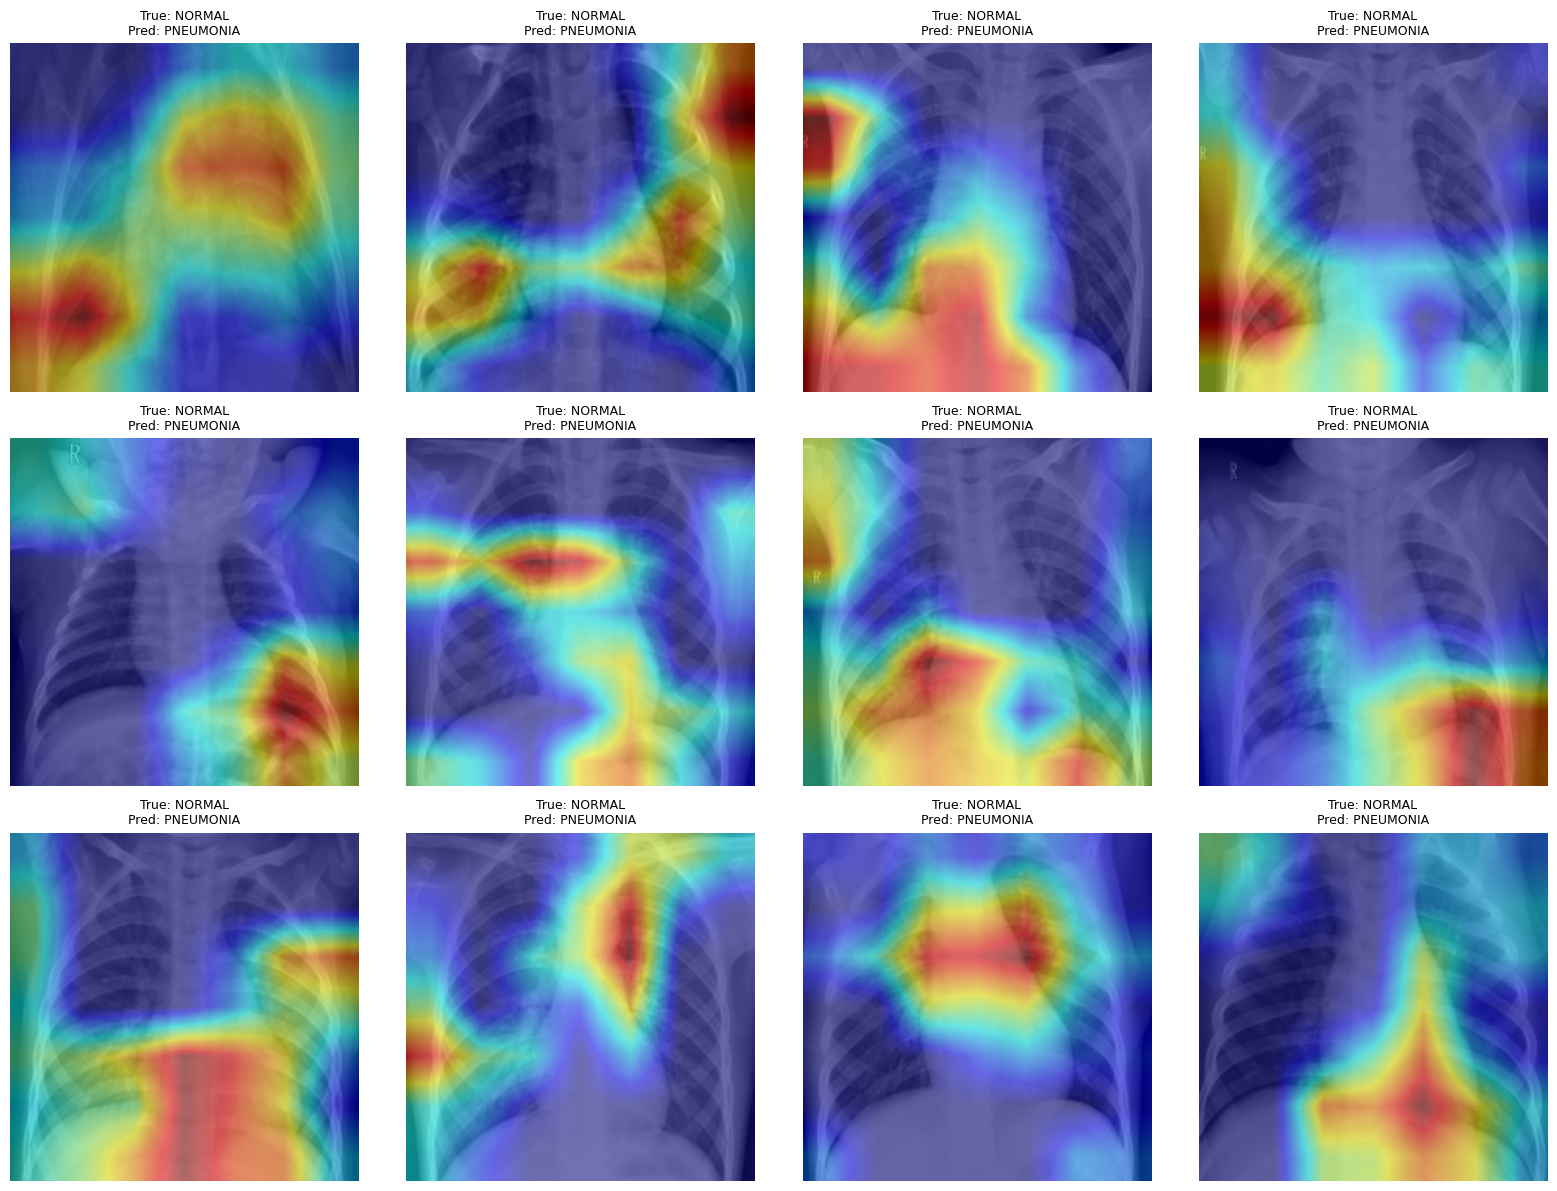

In [184]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, idx in enumerate(false_positive_indices[:12]):  # show first 12
    image_tensor, true_label = test_dataset[idx]
    input_tensor = image_tensor.unsqueeze(0).to(device)  # add batch dimension

    cam = gradcam.generate(input_tensor, class_idx=1)  # class_idx=1 = PNEUMONIA (what it wrongly predicted)

    display_img = unnormalize(image_tensor)  # skip this line if you didn't normalize
    show_gradcam(display_img, cam, true_label=true_label, pred_label=1,
                 class_names=class_names, ax=axes[i])

plt.tight_layout()
plt.show()

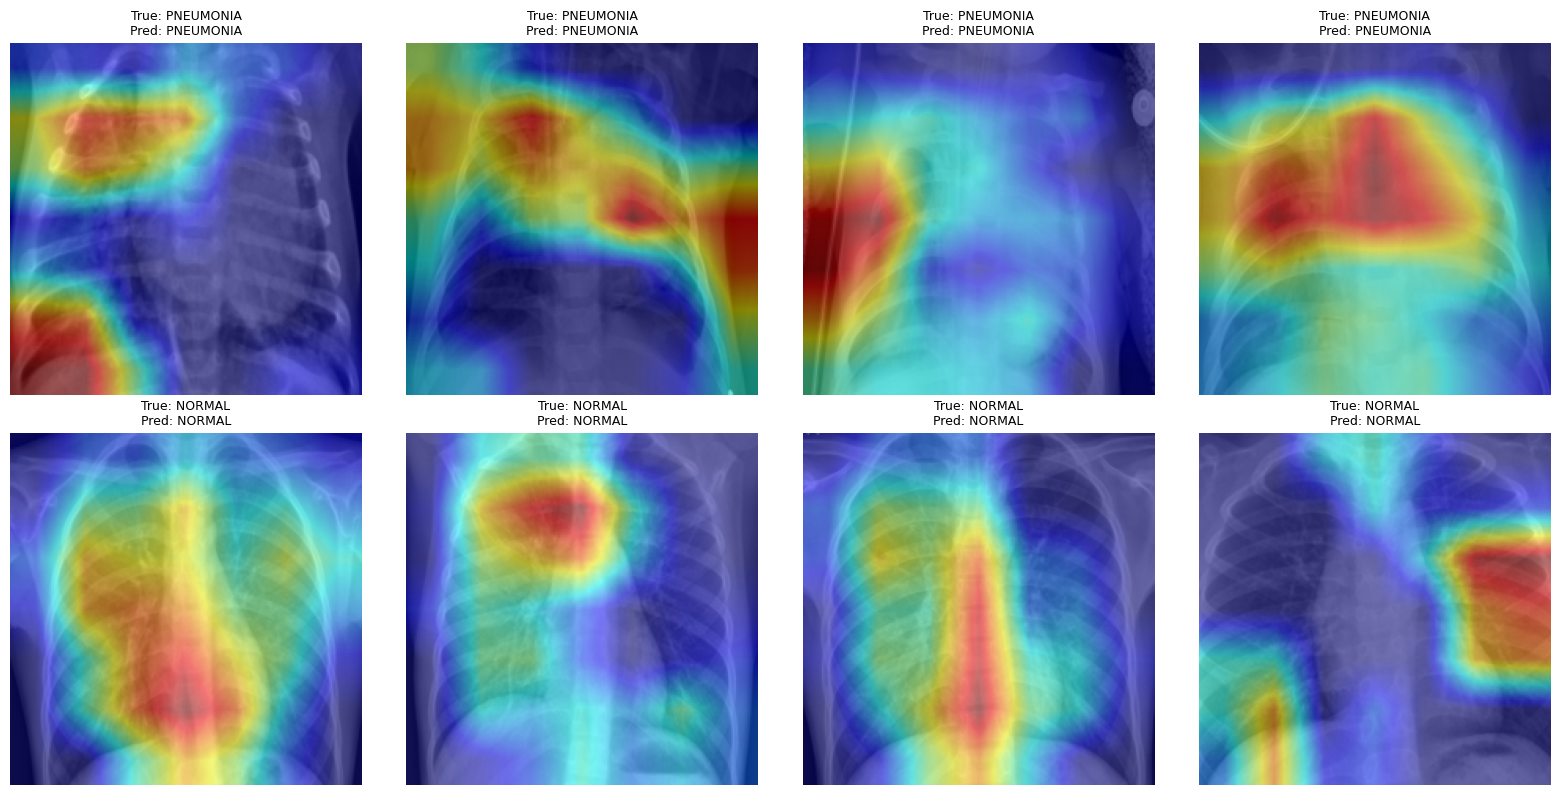

In [185]:
correct_pneumonia_idx = np.where((labels_arr == 1) & (preds_at_threshold == 1))[0][:4]
correct_normal_idx = np.where((labels_arr == 0) & (preds_at_threshold == 0))[0][:4]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, idx in enumerate(correct_pneumonia_idx):
    image_tensor, true_label = test_dataset[idx]
    input_tensor = image_tensor.unsqueeze(0).to(device)
    cam = gradcam.generate(input_tensor, class_idx=1)
    display_img = unnormalize(image_tensor)
    show_gradcam(display_img, cam, true_label, 1, class_names, ax=axes[0][i])

for i, idx in enumerate(correct_normal_idx):
    image_tensor, true_label = test_dataset[idx]
    input_tensor = image_tensor.unsqueeze(0).to(device)
    cam = gradcam.generate(input_tensor, class_idx=0)
    display_img = unnormalize(image_tensor)
    show_gradcam(display_img, cam, true_label, 0, class_names, ax=axes[1][i])

plt.tight_layout()
plt.show()
